In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import BaseEstimator
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import mlflow
import copy
import joblib

In [2]:
df = pd.read_excel("./archive/Obesity_Dataset.xlsx")
df.rename(columns={"Class": "Target"}, inplace=True)
df["Target"] = df["Target"].map({4: 3, 3: 2, 2: 1, 1: 0})

feature_names = list(df.columns)
feature_names.pop(-1)
target_names = ["Underweight", "Normal", "Overweight", "Obesity"]

df.head()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Target
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4,1
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3,1
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4,1
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4,1
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2,1


In [3]:
df.describe()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Target
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1.557764,33.115528,167.741615,1.834783,1.729193,2.063354,1.872050,2.395652,1.69441,2.108696,1.822360,3.265839,2.012422,2.667081,1.678882
std,0.496806,9.835076,7.979873,0.371492,0.444515,0.746043,0.638345,1.010501,0.46080,0.814710,0.382328,1.343035,0.697929,1.518388,0.815855
min,1.000000,18.000000,150.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,25.000000,161.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.00000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,32.000000,168.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000
75%,2.000000,41.000000,174.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.00000,3.000000,2.000000,4.000000,2.000000,4.000000,2.000000
max,2.000000,54.000000,193.000000,2.000000,2.000000,3.000000,3.000000,4.000000,2.00000,3.000000,2.000000,5.000000,3.000000,5.000000,3.000000


In [4]:
X = df.drop("Target", axis=1)
X.head()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2


In [5]:
y = df["Target"].to_frame()
y.head()

,Target
0,1
1,1
2,1
3,1
4,1


In [6]:
print(df.isnull().sum())
print(f"\nNombre de donnée manquante : {df.isnull().sum().sum()}")

Sex                                  0
Age                                  0
Height                               0
Overweight_Obese_Family              0
Consumption_of_Fast_Food             0
Frequency_of_Consuming_Vegetables    0
Number_of_Main_Meals_Daily           0
Food_Intake_Between_Meals            0
Smoking                              0
Liquid_Intake_Daily                  0
Calculation_of_Calorie_Intake        0
Physical_Excercise                   0
Schedule_Dedicated_to_Technology     0
Type_of_Transportation_Used          0
Target                               0
dtype: int64

Nombre de donnée manquante : 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print("Échelle des données après standardisation : ")
X_train_scaled.head()

Échelle des données après standardisation : 


,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used
0,-1.134788,1.123658,0.802301,0.436335,0.603661,-0.09808,0.208887,-0.395807,-1.498110,1.106508,0.451374,-1.718175,-1.482827,-1.125501
1,-1.134788,1.633440,1.176753,0.436335,0.603661,-0.09808,0.208887,1.564958,-1.498110,-0.122097,-2.215459,0.548479,1.404371,-1.125501
2,0.881222,-0.711558,-0.820326,0.436335,0.603661,-0.09808,0.208887,-0.395807,0.667508,1.106508,0.451374,-0.962624,-0.039228,-0.465972
3,-1.134788,1.123658,0.927118,0.436335,0.603661,-0.09808,0.208887,-0.395807,-1.498110,-0.122097,0.451374,-1.718175,-1.482827,-1.125501
4,0.881222,1.633440,-1.319596,0.436335,0.603661,-0.09808,0.208887,-0.395807,0.667508,-1.350702,0.451374,-1.718175,-0.039228,-1.125501


In [9]:
print(
    f"Présence de doublon dans les données d'entraînement ?\n{X_train_scaled.duplicated().any()}"
)

Présence de doublon dans les données d'entraînement ?
False


In [10]:
# Classification binaire


class RegressionLogistiqueBinaire(BaseEstimator):
    """Régression logistique binaire"""

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.theta = None
        self.bias = None

    def fit(self, X, y):
        """Entraîner le modèle"""
        self.theta, self.bias = self.stochastic_gradient_ascent(X, y)
        return self

    def predict(self, X, seuil=0.5):
        """Classes prédites"""
        z = self.fonction_reg(X)
        proba = self.sigmoid(z)
        return (proba >= seuil).astype(int)

    def predict_proba(self, X):
        """Probabilités prédites"""
        z = self.fonction_reg(X)
        proba = self.sigmoid(z)
        return proba

    def sigmoid(self, z):
        """Fonction sigmoide(Probabilité)"""
        return 1 / (1 + np.exp(-z))

    def fonction_reg(self, X):
        """Valeurs de la rélation linéaire"""
        return X.dot(self.theta) + self.bias

    def stochastic_gradient_ascent(self, X, y):
        """Algorithme du SGA"""
        m, n = X.shape
        self.theta = np.zeros(n)
        self.bias = 0

        for epoch in range(self.epochs):
            for i in range(m):
                xi = X[i, :]
                yi = y[i]

                z = self.fonction_reg(xi)
                h = self.sigmoid(z)

                error = yi - h
                grad_theta, grad_bias = error * xi, error

                self.theta = self.theta + self.learning_rate * grad_theta
                self.bias = self.bias + self.learning_rate * grad_bias

        return self.theta, self.bias

In [11]:
# Classification multiclasse


class RegressionLogistiqueMultiClasse(BaseEstimator):
    """Régression logistique multiclasse (One-vs-Rest)"""

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.models = []
        self.classes = None

    def fit(self, X, y):
        """Entraîner un modèle binaire pour chaque classe"""
        self.classes = np.unique(y)
        self.models = []

        for c in self.classes:
            y_binary = (y == c).astype(int)

            theta, bias = self.stochastic_gradient_ascent(
                X, y_binary, learning_rate=self.learning_rate, epochs=self.epochs
            )

            self.models.append((theta, bias))

        return self

    def predict(self, X):
        """Classe avec probabilité max"""
        probas = self.predict_proba(X)
        return self.classes[np.argmax(probas, axis=1)]

    def predict_proba(self, X):
        """Probabilités pour chaque classe"""
        probas = []

        for theta, bias in self.models:
            z = self.fonction_reg(X, theta, bias)
            proba = self.sigmoid(z)
            probas.append(proba)

        return np.column_stack(probas)

    def sigmoid(self, z):
        """Fonction sigmoide(Probabilité)"""
        return 1 / (1 + np.exp(-z))

    def fonction_reg(self, X, theta, bias):
        """Valeurs de la rélation linéaire"""
        return X.dot(theta) + bias

    def stochastic_gradient_ascent(self, X, y, learning_rate, epochs):
        """Algorithme du SGA"""
        m, n = X.shape
        theta = np.zeros(n)
        bias = 0

        for epoch in range(epochs):
            for i in range(m):
                xi = X[i, :]
                yi = y[i]

                z = self.fonction_reg(xi, theta, bias)
                h = self.sigmoid(z)

                error = yi - h
                grad_theta, grad_bias = error * xi, error

                theta = theta + learning_rate * grad_theta
                bias = bias + learning_rate * grad_bias

        return theta, bias

In [12]:
reg_log = RegressionLogistiqueMultiClasse()
reg_log.fit(X_train_scaled.values, y_train.values)

,learning_rate,0.01
,epochs,100


In [13]:
y_pred_log = reg_log.predict(X_test_scaled)
print(f"SGA LogReg Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"SGA LogReg F1-score: {f1_score(y_test, y_pred_log, average='weighted'):.4f}")

SGA LogReg Accuracy: 0.7267
SGA LogReg F1-score: 0.7159


In [14]:
model_bay = GaussianNB()
model_bay.fit(X_train_scaled, np.ravel(y_train))

,priors,None
,var_smoothing,1e-09


In [15]:
y_pred_bay = model_bay.predict(X_test_scaled)
print(f"Naives Bayes Accuracy: {accuracy_score(y_test, y_pred_bay):.4f}")
print(f"Naives Bayes F1-score: {f1_score(y_test, y_pred_bay, average='weighted'):.4f}")

Naives Bayes Accuracy: 0.4161
Naives Bayes F1-score: 0.4464


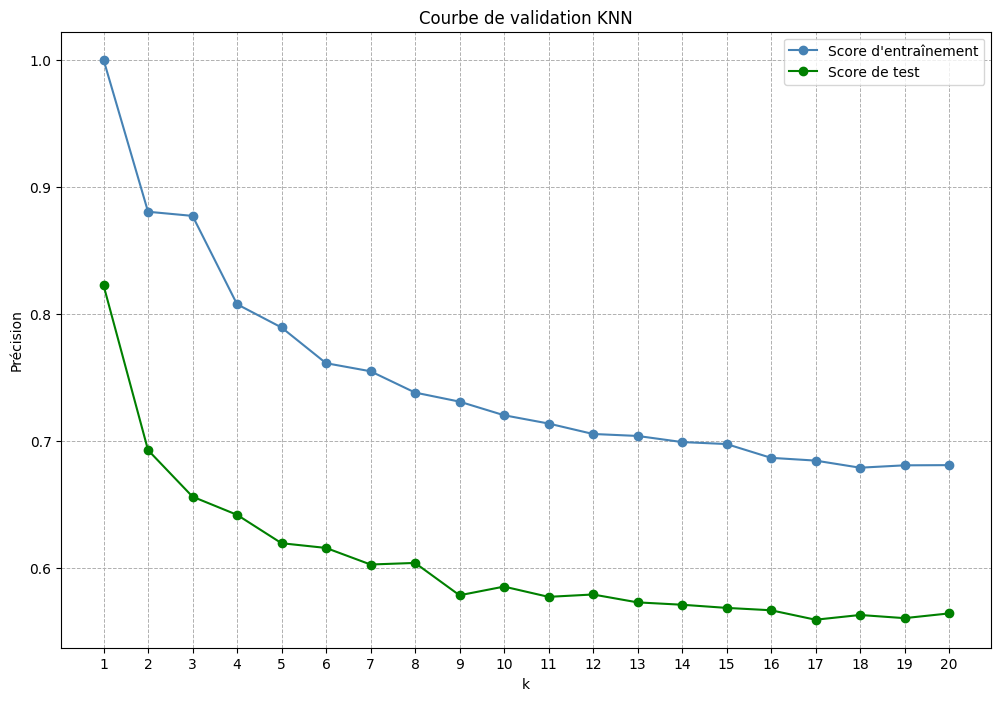

In [ ]:
k_values = np.arange(1, 21)

train_scores, test_scores = validation_curve(
    KNeighborsClassifier(),
    X,
    np.ravel(y),
    param_name="n_neighbors",
    param_range=k_values,
    cv=5,
    scoring="accuracy",
)

train_scores = np.mean(train_scores, axis=1)
test_scores = np.mean(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.plot(k_values, train_scores, c="steelblue", marker="o", label="Score d'entraînement")
plt.plot(k_values, test_scores, c="green", marker="o", label="Score de test")
plt.xticks(k_values)
plt.xlabel("k")
plt.ylabel("Précision")
plt.legend()
plt.grid(True, ls="--", lw=0.7)
plt.title("Courbe de validation KNN")
plt.show()

In [ ]:
k_optimal = 1
knn_best = KNeighborsClassifier(n_neighbors=k_optimal)
knn_best.fit(X_train_scaled, np.ravel(y_train)) 

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
y_pred_knn = knn_best.predict(X_test_scaled)
accuracy_score_knn = accuracy_score(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {accuracy_score_knn:.4f}")
print(f"KNN F1-score: {f1_score_knn:.4f}")

KNN Accuracy: 0.7640
KNN F1-score: 0.7647


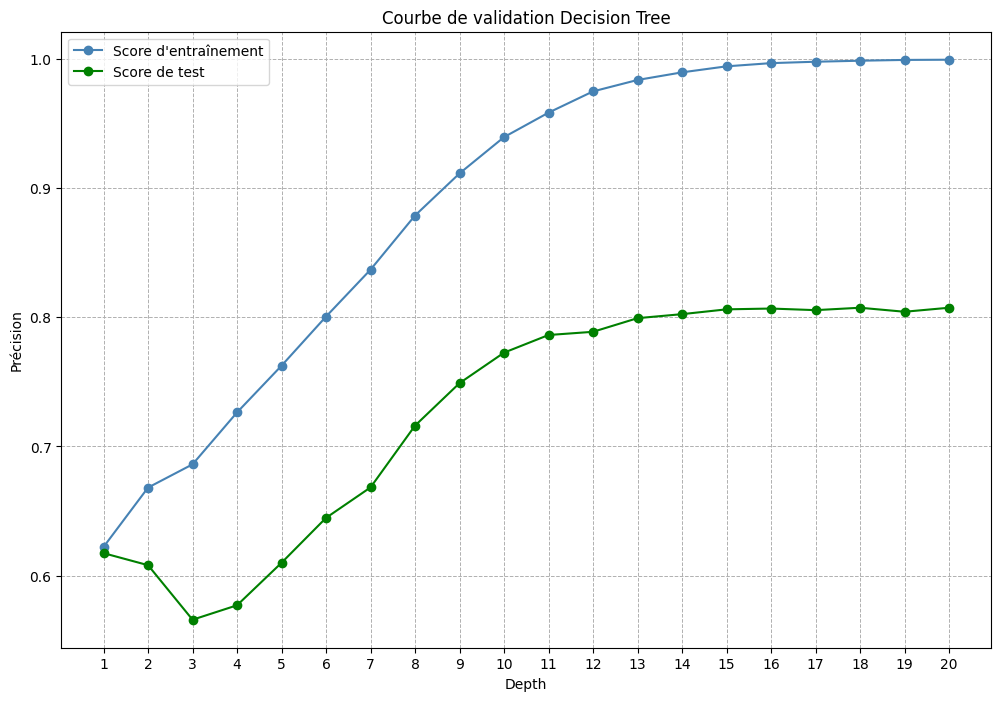

In [19]:
depth_values = np.arange(1, 21)

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X,
    np.ravel(y),
    param_name="max_depth",
    param_range=depth_values,
    cv=5,
    scoring="accuracy",
)

train_scores, test_scores = np.mean(train_scores, axis=1), np.mean(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.plot(depth_values, train_scores, c="steelblue", marker="o", label="Score d'entraînement")
plt.plot(depth_values, test_scores, c="green", marker="o", label="Score de test")
plt.xticks(depth_values)
plt.xlabel("Depth")
plt.ylabel("Précision")
plt.legend()
plt.grid(True, ls="--", lw=0.7)
plt.title("Courbe de validation Decision Tree")
plt.show()

In [20]:
depth_optimal = 14
model_dt = DecisionTreeClassifier(max_depth=depth_optimal, random_state=42)
model_dt.fit(X_train_scaled, np.ravel(y_train))

,criterion,'gini'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred_dt = model_dt.predict(X_test_scaled)
accuracy_score_dt = accuracy_score(y_test, y_pred_dt)
f1_score_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Decision Tree Accuracy: {accuracy_score_dt:.4f}")
print(f"Decision Tree F1-score: {f1_score_dt:.4f}")

Decision Tree Accuracy: 0.7795
Decision Tree F1-score: 0.7787


In [22]:
importances = model_dt.feature_importances_

df_importances = pd.DataFrame({"feature": feature_names, "importances": importances})
df_importances = df_importances.query("importances > 0")
df_importances

,feature,importances
0,Sex,0.060400
1,Age,0.348465
2,Height,0.096365
3,Overweight_Obese_Family,0.025889
4,Consumption_of_Fast_Food,0.025531
5,Frequency_of_Consuming_Vegetables,0.090077
6,Number_of_Main_Meals_Daily,0.091306
7,Food_Intake_Between_Meals,0.040303
8,Smoking,0.046003
9,Liquid_Intake_Daily,0.035396


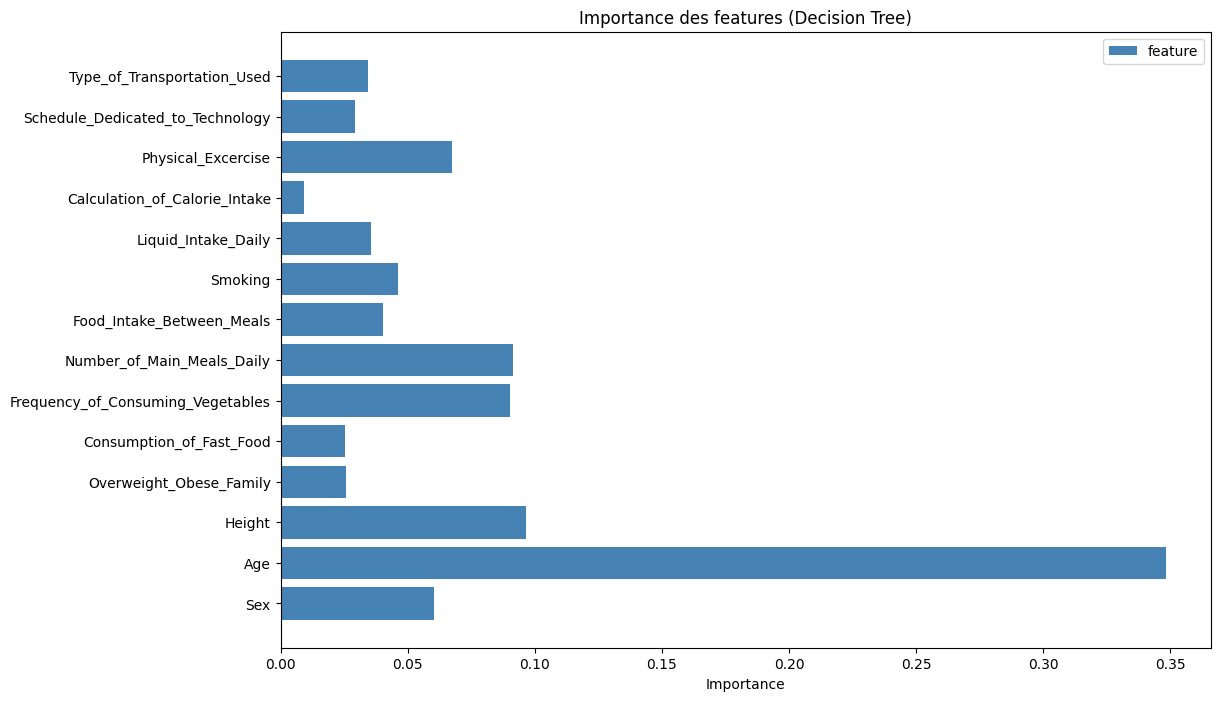

In [23]:
plt.figure(figsize=(12, 8))

plt.barh(
    df_importances["feature"],
    df_importances["importances"],
    color="steelblue",
    label="feature",
)
plt.xlabel("Importance")
plt.title("Importance des features (Decision Tree)")
plt.legend()
plt.show()

In [24]:
adaboost = AdaBoostClassifier(estimator=model_dt, random_state=42)
adaboost.fit(X_train_scaled, np.ravel(y_train))

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [25]:
y_pred_ada = adaboost.predict(X_test_scaled)
accuracy_score_ada = accuracy_score(y_test, y_pred_ada)
f1_score_ada = f1_score(y_test, y_pred_ada, average='weighted')

print(
    f"Decision Tree boosting with AbaBoost Accuracy: {accuracy_score_ada:.4f}"
)
print(
    f"Decision Tree boosting with AbaBoost F1-score: {f1_score_ada:.4f}"
)

Decision Tree boosting with AbaBoost Accuracy: 0.8758
Decision Tree boosting with AbaBoost F1-score: 0.8759


In [26]:
svm_linear = LinearSVC(random_state=42)
svm_linear.fit(X_train_scaled, np.ravel(y_train))

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [27]:
y_pred_svmlin = svm_linear.predict(X_test_scaled)
accuracy_score_svmlin = accuracy_score(y_test, y_pred_svmlin)
f1_score_svmlin = f1_score(y_test, y_pred_svmlin, average='weighted')

print(f"SVM Linear Accuracy: {accuracy_score_svmlin:.4f}")
print(f"SVM Linear F1-score: {f1_score_svmlin:.4f}")

SVM Linear Accuracy: 0.7205
SVM Linear F1-score: 0.7132


In [28]:
# Score de validation assez gourmand prend beaucoup de temps on passe à un autre approche :

param_grid = {"C": [0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(
    estimator=SVC(kernel="linear", random_state=42),
    param_grid=param_grid,
    cv=5,
    verbose=1,
    scoring="accuracy"
)
grid.fit(X_train_scaled, np.ravel(y_train))

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,SVC(kernel='l...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [29]:
C_optimal = grid.best_params_["C"]
svm_soft = grid.best_estimator_
y_pred_svmsoft = svm_soft.predict(X_test_scaled)
accuracy_score_svmsoft = accuracy_score(y_test, y_pred_svmsoft)
f1_score_svmlin = f1_score(y_test, y_pred_svmlin, average='weighted')
f1_score_svmsoft = f1_score(y_test, y_pred_svmsoft, average='weighted')

print(f"SVM Soft Margin Accuracy: {accuracy_score_svmsoft:.4f}")
print(f"SVM Soft Margin F1 Score: {f1_score_svmsoft:.4f}")

SVM Soft Margin Accuracy: 0.7236
SVM Soft Margin F1 Score: 0.7236


In [30]:
# Score de validation assez gourmand prend beaucoup de temps on passe à un autre approche :

param_grid = {"C": [0.1, 1, 10, 100, 1000], "gamma": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=42),
    param_grid=param_grid,
    cv=5,
    verbose=1,
    scoring="accuracy",
)

grid.fit(X_train_scaled, np.ravel(y_train))

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [31]:
C_optimal, k_optimal = grid.best_params_["C"], grid.best_params_["gamma"]
svm_rbf = grid.best_estimator_
y_pred_svmrbf = svm_rbf.predict(X_test_scaled)
accuracy_score_svmrbf = accuracy_score(y_test, y_pred_svmrbf)
f1_score_svmrbf = f1_score(y_test, y_pred_svmrbf, average='weighted')


print(f"SVM Kernel Accuracy: {accuracy_score_svmrbf:.4f}")
print(f"SVM Kernel F1-score: {f1_score_svmrbf:.4f}")

SVM Kernel Accuracy: 0.7919
SVM Kernel F1-score: 0.7913


In [32]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_reduced = lda.fit_transform(X_train_scaled, np.ravel(y_train))

In [33]:
model_bay_ = copy.deepcopy(model_bay)
adaboost_ = copy.deepcopy(adaboost)
model_bay_.fit(X_reduced, np.ravel(y_train))
adaboost_.fit(X_reduced, np.ravel(y_train))

y_pred_bay = model_bay_.predict(X_reduced)
y_pred_ada = adaboost_.predict(X_reduced)

print("Modèles re-entraînés avec les données reduites")

Modèles re-entraînés avec les données reduites


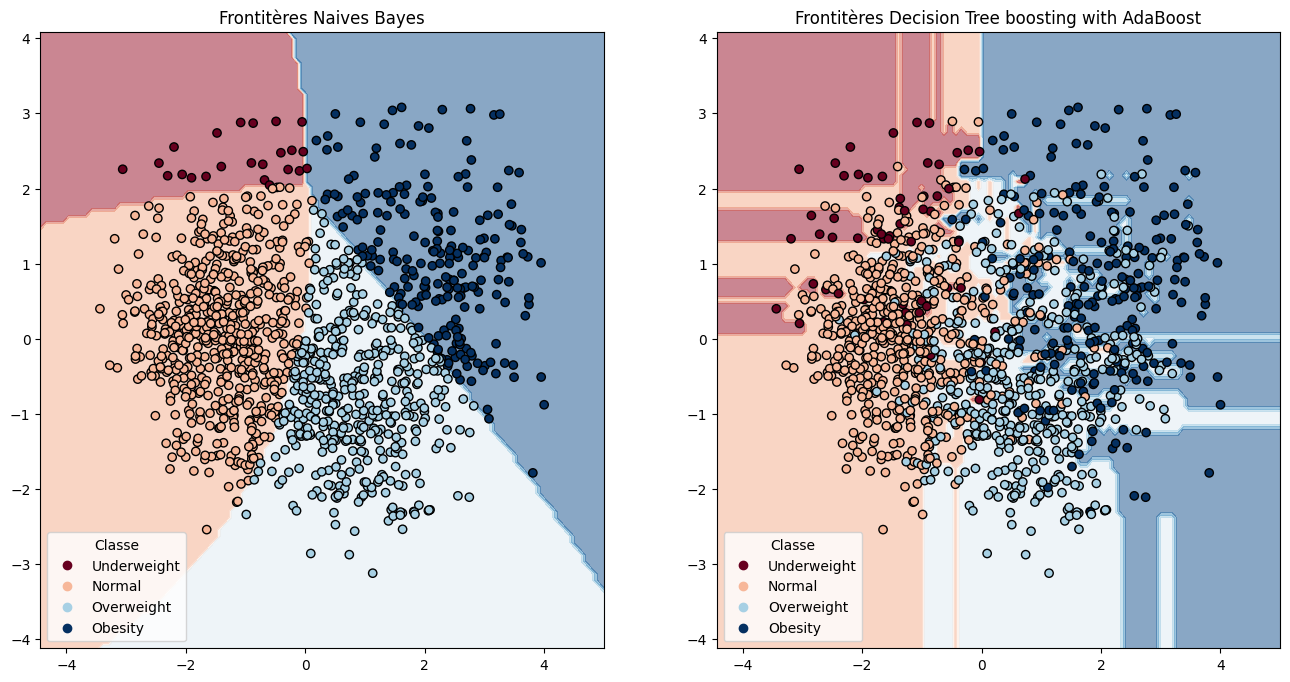

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

disp1 = DecisionBoundaryDisplay.from_estimator(
    model_bay_,
    X_reduced,
    cmap=plt.cm.RdBu,
    ax=ax[0],
    response_method="predict",
    alpha=0.5,
)

disp2 = DecisionBoundaryDisplay.from_estimator(
    adaboost_,
    X_reduced,
    cmap=plt.cm.RdBu,
    ax=ax[1],
    response_method="predict",
    alpha=0.5,
)

scatter1 = ax[0].scatter(
    X_reduced[:, 0], X_reduced[:, 1], c=y_pred_bay, cmap=plt.cm.RdBu, edgecolor="k"
)
scatter2 = ax[1].scatter(
    X_reduced[:, 0], X_reduced[:, 1], c=y_pred_ada, cmap=plt.cm.RdBu, edgecolor="k"
)

handles1, _ = scatter1.legend_elements()

ax[0].legend(handles1, target_names, title="Classe")
ax[1].legend(handles1, target_names, title="Classe")
ax[0].set_title("Frontitères Naives Bayes")
ax[1].set_title("Frontitères Decision Tree boosting with AdaBoost")

plt.show()

In [35]:
classe, count = np.unique(y_train.values, return_counts=True)
classe_minor = classe[np.argmin(count)]
classe_major = classe[np.argmax(count)]

print(f"La classe minoritaire est : {target_names[classe_minor]}")
print(f"La classe majoritaire est : {target_names[classe_major]}")

La classe minoritaire est : Underweight
La classe majoritaire est : Normal


In [36]:
y_train_noisy = copy.deepcopy(y_train)

indices_minor = y_train[y_train == classe_minor].index

n_flip = int(len(indices_minor) * 0.05)

np.random.seed(42)
flip_indices = np.random.choice(indices_minor, size=n_flip, replace=False)

y_train_noisy.loc[flip_indices] = np.random.randint(1, 4)

In [37]:
# On sélectionne les 3 meilleurs modèles en se basant sur l'accuracy_score et du f1_score

top_3 = {
    'Decision Tree with AdaBoost' : adaboost,
    'SVM RBF' : svm_rbf,
    'KNN' : knn_best
}

In [38]:
resultats = []

for nom in top_3.keys():
    if "AdaBoost" in nom:
        model_clean = adaboost
        model_noisy = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
            random_state=42,
        )
    elif "RBF" in nom:
        model_clean = svm_rbf
        model_noisy = SVC(kernel="rbf", C=1, gamma=0.1, random_state=42)
    else:
        model_clean = knn_best
        model_noisy = KNeighborsClassifier(n_neighbors=11)

    model_clean.fit(X_train_scaled, np.ravel(y_train))
    y_pred_clean = model_clean.predict(X_test_scaled)
    acc_clean = accuracy_score(y_test, y_pred_clean)
    f1_clean = f1_score(y_test, y_pred_clean, average='weighted')

    model_noisy.fit(X_train_scaled, np.ravel(y_train_noisy))
    y_pred_noisy = model_noisy.predict(X_test_scaled)
    acc_noisy = accuracy_score(y_test, y_pred_noisy)
    f1_noisy = f1_score(y_test, y_pred_noisy, average='weighted')

    acc_drop = (acc_clean - acc_noisy) * 100
    f1_drop = (f1_clean - f1_noisy) * 100

    resultats.append(
        {
            "nom": nom,
            "acc_drop": acc_drop,
            "f1_drop": f1_drop,
        }
    )

In [39]:
noms = [r["nom"] for r in resultats]
acc_drops = [r["acc_drop"] for r in resultats]
f1_drops = [r["f1_drop"] for r in resultats]

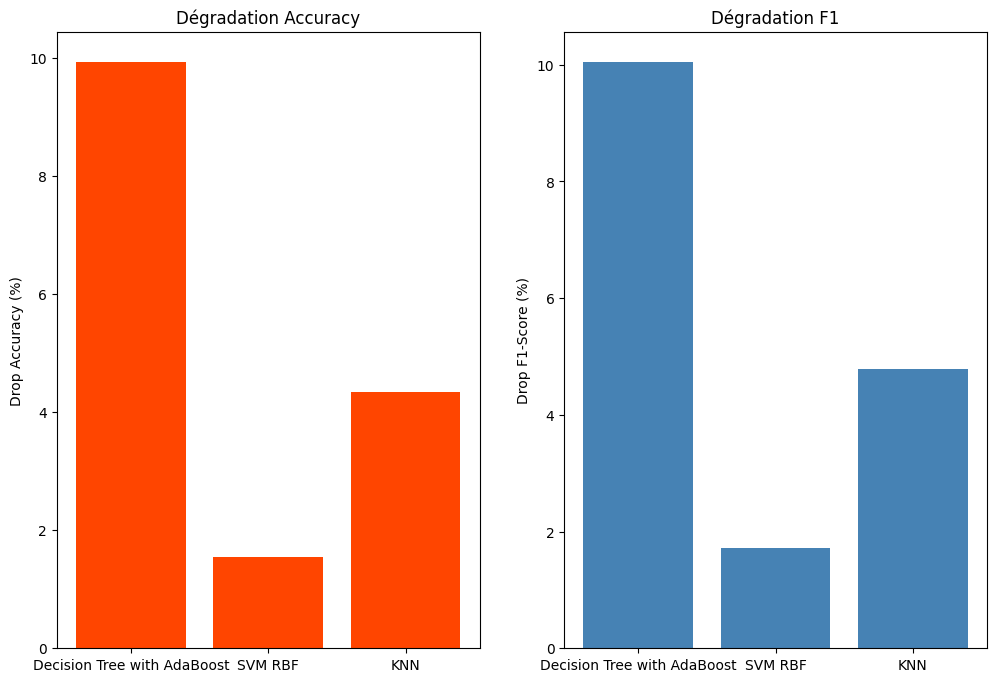

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

# Graphique 1: Drop en Accuracy
ax[0].bar(noms, acc_drops, color="orangered")
ax[0].set_ylabel("Drop Accuracy (%)")
ax[0].set_title("Dégradation Accuracy")

# Graphique 2: Drop en F1
ax[1].bar(noms, f1_drops, color="steelblue")
ax[1].set_ylabel("Drop F1-Score (%)")
ax[1].set_title("Dégradation F1")

plt.show()

In [41]:
mlflow.set_experiment("TP_Classification")


def log_model_results(model_name, params, metrics, model):
    """Logs the results of a model in MLflow."""
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name="model")
        print(f"MLflow Run '{model_name}' logged.")

2026/01/28 23:06:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/28 23:06:09 INFO mlflow.store.db.utils: Updating database tables
2026/01/28 23:06:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 23:06:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/28 23:06:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 23:06:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [42]:
# Sauvegarde des 3 meilleurs modèles

for nom in top_3.keys():
    if "AdaBoost" in nom:
        params = {"max_depth": depth_optimal}
        metrics = {"accuracy_score": accuracy_score_dt, "f1_score": f1_score_dt}
        log_model_results("DecisionTreeClassifier", params, metrics, model_dt)
    elif "RBF" in nom:
        params = {"C": 100, "gamma": 0.1}
        metrics = {"accuracy_score": accuracy_score_svmrbf, "f1_score": f1_score_svmrbf}
        log_model_results("SVM", params, metrics, svm_rbf)
    else:
        params = {"K": k_optimal}
        metrics = {"accuracy_score": accuracy_score_knn, "f1_score": f1_score_knn}
        log_model_results("KNN", params, metrics, knn_best)

MLflow Run 'DecisionTreeClassifier' logged.
MLflow Run 'SVM' logged.
MLflow Run 'KNN' logged.


In [43]:
# Re-entreînement pour le MLOps deployment

scaler_deploy = StandardScaler()
X_reduced = scaler_deploy.fit_transform(X)
adaboost = AdaBoostClassifier(estimator=model_dt, random_state=42)
adaboost.fit(X_train_scaled, np.ravel(y_train))

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [44]:
joblib.dump(scaler_deploy, "scaler.pkl")
joblib.dump(adaboost, "adaboost.pkl")

['adaboost.pkl']